In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import psutil
from tqdm import tqdm
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# **1. Entrenamiento por Lotes**

| Método        | Tamaño del lote              | Frecuencia de actualización     | Estabilidad | Costo computacional | ¿Cuándo usar? |
|---------------|------------------------------|----------------------------------|-------------|---------------------|---------------|
| Batch GD      | Todo el conjunto de datos    | 1 actualización por época        | Alta        | Alto                | Cuando se tiene suficiente memoria y se prioriza estabilidad |
| Mini-Batch GD | Pequeños lotes (ej. 32, 64)  | Varias actualizaciones por época | Balanceada  | Moderado            | Cuando se busca un equilibrio entre estabilidad y eficiencia |
| SGD           | 1 dato por iteración         | Se actualiza en cada ejemplo     | Baja        | Bajo                | Cuando se trabaja con grandes volúmenes de datos o entrenamiento online |

In [2]:
# Fijar semillas garantiza que los experimentos sean
# reproducibles: los mismos datos y pesos iniciales
# en cada ejecución, facilitando la comparación justa.
SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

print("Dependencias cargadas y semillas fijadas.")

Dependencias cargadas y semillas fijadas.


In [3]:
# ============================================================
# Generación y Preparación del Dataset
# ============================================================
# Propósito: Crear un problema de clasificación binaria NO
# lineal (dos círculos concéntricos). Este tipo de dato
# desafía a los optimizadores porque ninguna línea recta
# puede separar las clases — requiere una frontera curva.
# ============================================================

# --- Hiperparámetros del dataset ---
TOTAL_MUESTRAS    = 2000   # Cantidad total de puntos generados
FACTOR_SEPARACION = 0.3    # Qué tan separados están los círculos (0 = muy juntos)
NIVEL_RUIDO       = 0.2    # Cuánto ruido gaussiano se añade a los puntos
PROPORCION_PRUEBA = 0.2    # 20 % del dataset se reserva para evaluación

# make_circles genera dos clases (0 y 1) en forma de anillos
# concéntricos. StandardScaler normaliza las features para que
# tengan media 0 y desviación estándar 1, lo que acelera el
# aprendizaje al evitar escalas dispares entre variables.
coordenadas_raw, etiquetas_raw = make_circles(
    n_samples=TOTAL_MUESTRAS,
    factor=FACTOR_SEPARACION,
    noise=NIVEL_RUIDO,
    random_state=SEMILLA
)
coordenadas_normalizadas = StandardScaler().fit_transform(coordenadas_raw)

# PyTorch trabaja con tensores (análogos a arrays de NumPy
# pero con soporte para diferenciación automática y GPU).
# FloatTensor → precisión de 32 bits, estándar en deep learning.
tensor_coordenadas = torch.FloatTensor(coordenadas_normalizadas)
tensor_etiquetas   = torch.FloatTensor(etiquetas_raw).reshape(-1, 1)
# reshape(-1, 1): convierte el vector plano [n] → matriz [n, 1]
# que es el formato esperado por BCELoss más adelante.

# División estratificada en conjunto de entrenamiento y prueba
(coordenadas_entrenamiento, coordenadas_prueba,
 etiquetas_entrenamiento,   etiquetas_prueba) = train_test_split(
    tensor_coordenadas, tensor_etiquetas,
    test_size=PROPORCION_PRUEBA,
    random_state=SEMILLA
)

print(f"Dataset listo:")
print(f"   Entrenamiento : {coordenadas_entrenamiento.shape[0]} muestras")
print(f"   Prueba        : {coordenadas_prueba.shape[0]} muestras")

Dataset listo:
   Entrenamiento : 1600 muestras
   Prueba        : 400 muestras


In [4]:
# ============================================================
# Arquitectura de la Red Neuronal
# ============================================================
# Propósito: Definir un clasificador binario simple de dos
# capas. Esta celda es independiente del optimizador, lo que
# permite reutilizar la arquitectura con distintos métodos GD.
#
# Arquitectura:
#   Entrada (2) → Capa Oculta (10, ReLU) → Salida (1, Sigmoid)
#
# ¿Por qué estas funciones de activación?
#   - ReLU  : introduce no linealidad sin saturación, evita
#             el problema del gradiente que desaparece.
#   - Sigmoid: mapea la salida al rango [0, 1], interpretable
#             como probabilidad de pertenecer a la clase 1.
# ============================================================

class ClasificadorBinario(nn.Module):
    """
    Red neuronal de dos capas para clasificación binaria.
    
    Entrada:  vector de 2 características (x, y del plano)
    Salida:   escalar en [0, 1] → probabilidad de clase 1
    """

    def __init__(self, neuronas_ocultas: int = 10):
        super(ClasificadorBinario, self).__init__()

        # Capa oculta: aprende representaciones intermedias
        self.capa_oculta = nn.Linear(2, neuronas_ocultas)

        # Capa de salida: colapsa a una única probabilidad
        self.capa_salida = nn.Linear(neuronas_ocultas, 1)

        # Activaciones reutilizables (no tienen parámetros)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Paso hacia adelante: transforma la entrada en una predicción."""
        x = self.relu(self.capa_oculta(x))   # Extracción de features
        x = self.sigmoid(self.capa_salida(x)) # Conversión a probabilidad
        return x


# Verificación rápida de la arquitectura
modelo_prueba = ClasificadorBinario()
print("Arquitectura definida:")
print(modelo_prueba)
print(f"\n   Parámetros entrenables: "
      f"{sum(p.numel() for p in modelo_prueba.parameters()):,}")

Arquitectura definida:
ClasificadorBinario(
  (capa_oculta): Linear(in_features=2, out_features=10, bias=True)
  (capa_salida): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

   Parámetros entrenables: 41


In [5]:
# ============================================================
# Función de Entrenamiento Modular
# ============================================================
# Propósito: Encapsular el bucle de entrenamiento de forma
# genérica. Acepta CUALQUIER optimizador de PyTorch y
# CUALQUIER tamaño de lote, lo que permite comparar los tres
# métodos de descenso de gradiente sin duplicar código.
#
# Métodos que se compararán:
#   - Batch GD      : lote = dataset completo (convergencia suave)
#   - Mini-Batch GD : lote = 32 muestras      (balance óptimo)
#   - SGD puro      : lote = 1 muestra        (muy ruidoso)
# ============================================================

def entrenar_modelo(
    optimizador,
    tamanio_lote: int,
    nombre_metodo: str,
    epocas: int = 100
) -> tuple[float, float, list[float]]:
    """
    Entrena un ClasificadorBinario y mide su rendimiento.

    Parámetros
    ----------
    optimizador    : instancia de torch.optim (SGD, Adam, etc.)
    tamanio_lote   : número de muestras por actualización de pesos
    nombre_metodo  : etiqueta para la barra de progreso
    epocas         : número de pasadas completas sobre el dataset

    Retorna
    -------
    tiempo_ejecucion : segundos totales de entrenamiento
    uso_memoria      : MB adicionales consumidos durante el proceso
    historial_perdida: pérdida promedio por época
    """

    # Crear una instancia FRESCA del modelo para cada experimento.
    # Esto es crucial: garantiza que todos los métodos parten de
    # los mismos pesos iniciales y la comparación sea justa.
    modelo    = ClasificadorBinario()
    criterio  = nn.BCELoss()
    # BCELoss (Binary Cross-Entropy): penaliza predicciones
    # alejadas de la etiqueta real; ideal para clasificación binaria.

    # --- Medición de recursos ANTES del entrenamiento ---
    tiempo_inicio  = time.time()
    memoria_inicio = psutil.Process().memory_info().rss / (1024 ** 2)  # → MB

    historial_perdida = []

    for epoca in tqdm(range(epocas), desc=f"Entrenando {nombre_metodo}"):

        # Permutar los índices en cada época evita que el modelo
        # memorice el orden de los datos (crucial para SGD puro).
        indices_aleatorios = torch.randperm(coordenadas_entrenamiento.size(0))

        perdida_total_epoca = 0.0
        cantidad_lotes      = 0

        for inicio in range(0, coordenadas_entrenamiento.size(0), tamanio_lote):
            # Seleccionar el mini-lote actual
            indices_lote  = indices_aleatorios[inicio : inicio + tamanio_lote]
            lote_coords   = coordenadas_entrenamiento[indices_lote]
            lote_etiquetas = etiquetas_entrenamiento[indices_lote]

            # Ciclo estándar de PyTorch:
            optimizador.zero_grad()           # 1) Limpiar gradientes anteriores
            predicciones = modelo(lote_coords) # 2) Paso hacia adelante
            perdida = criterio(predicciones, lote_etiquetas) # 3) Calcular pérdida
            perdida.backward()                # 4) Retropropagación
            optimizador.step()                # 5) Actualizar pesos

            perdida_total_epoca += perdida.item()
            cantidad_lotes      += 1

        # Pérdida promedio de la época (normalizada por nº de lotes)
        historial_perdida.append(perdida_total_epoca / cantidad_lotes)

    # --- Medición de recursos DESPUÉS del entrenamiento ---
    tiempo_ejecucion = time.time() - tiempo_inicio
    memoria_final    = psutil.Process().memory_info().rss / (1024 ** 2)
    uso_memoria      = memoria_final - memoria_inicio

    return tiempo_ejecucion, uso_memoria, historial_perdida


print("Función de entrenamiento lista.")

Función de entrenamiento lista.


In [6]:
# ============================================================
# Experimento Comparativo
# ============================================================
# Propósito: Ejecutar los tres métodos de descenso de gradiente
# con idénticos hiperparámetros (lr, épocas, arquitectura) y
# registrar métricas de rendimiento para su posterior análisis.
# ============================================================

# --- Hiperparámetros compartidos ---
EPOCAS         = 200
TASA_APRENDIZAJE = 0.001

# Se instancia UN NUEVO ClasificadorBinario para cada experimento
# y se pasa al optimizador. Usar model.parameters() vincula el
# optimizador a los pesos específicos de esa instancia.

# ── Batch Gradient Descent ──────────────────────────────────
# Calcula el gradiente sobre TODO el dataset en cada paso.
# Ventaja: convergencia suave. Desventaja: lento y costoso en memoria.
optimizador_batch = optim.SGD(ClasificadorBinario().parameters(), lr=TASA_APRENDIZAJE)
tiempo_batch, memoria_batch, perdidas_batch = entrenar_modelo(
    optimizador_batch,
    tamanio_lote=len(coordenadas_entrenamiento),  # lote = dataset completo
    nombre_metodo="Batch GD",
    epocas=EPOCAS
)

# ── Mini-Batch Gradient Descent ─────────────────────────────
# Calcula el gradiente sobre subconjuntos de 32 muestras.
# Equilibrio práctico: ruidoso (escapa mínimos locales) pero estable.
optimizador_mini = optim.SGD(ClasificadorBinario().parameters(), lr=TASA_APRENDIZAJE)
tiempo_mini, memoria_mini, perdidas_mini = entrenar_modelo(
    optimizador_mini,
    tamanio_lote=32,
    nombre_metodo="Mini-Batch GD",
    epocas=EPOCAS
)

# ── Stochastic Gradient Descent (puro) ──────────────────────
# Actualiza los pesos tras CADA muestra individual.
# Ventaja: rápida adaptación. Desventaja: curva de pérdida muy ruidosa.
optimizador_sgd = optim.SGD(ClasificadorBinario().parameters(), lr=TASA_APRENDIZAJE)
tiempo_sgd, memoria_sgd, perdidas_sgd = entrenar_modelo(
    optimizador_sgd,
    tamanio_lote=1,  # lote = 1 muestra
    nombre_metodo="SGD puro",
    epocas=EPOCAS
)

# Empaquetar resultados en estructuras legibles
nombres_metodos  = ["Batch GD", "Mini-Batch GD", "SGD puro"]
tiempos          = [tiempo_batch, tiempo_mini, tiempo_sgd]
memorias         = [memoria_batch, memoria_mini, memoria_sgd]
historiales      = [perdidas_batch, perdidas_mini, perdidas_sgd]
colores          = ["#4C72B0", "#DD8452", "#55A868"]

print("\nResultados:")
for nombre, t, m in zip(nombres_metodos, tiempos, memorias):
    print(f"   {nombre:<16} → {t:.2f}s | {m:+.1f} MB")

Entrenando SGD puro: 100%|██████████| 200/200 [01:24<00:00,  2.36it/s]


Resultados:
   Batch GD         → 0.08s | +2.5 MB
   Mini-Batch GD    → 2.54s | +0.2 MB
   SGD puro         → 84.88s | -0.3 MB


# **2. Optimizadores**

In [7]:
# ============================================================
# Función de Pérdida y Superficie de Evaluación
# ============================================================
# Propósito: Definir la función de pérdida que todos los
# optimizadores intentarán minimizar, y pre-calcular la
# malla 3D que se usará como fondo visual en cada gráfico.
#
# f(x, y) = x² + y²  →  paraboloide con mínimo global en (0, 0)
# Es convexa: garantiza que TODOS los optimizadores convergen,
# lo que facilita comparar su velocidad y trayectoria.
# ============================================================


# --- Función de pérdida ---
def calcular_perdida(coord_x: float, coord_y: float):
    """
    Paraboloide simple centrado en el origen.
    Mínimo global exacto en (x=0, y=0) con pérdida = 0.
    Compatible con tensores de PyTorch (permite autograd).
    """
    return coord_x**2 + coord_y**2


# --- Malla de evaluación para la superficie 3D ---
# np.linspace genera 100 puntos equidistantes en [-2, 2]
# np.meshgrid combina los dos ejes en matrices 2D, necesarias
# para evaluar la función sobre una cuadrícula completa.
RANGO_MIN, RANGO_MAX, RESOLUCION_MALLA = -2, 2, 100

eje_x = np.linspace(RANGO_MIN, RANGO_MAX, RESOLUCION_MALLA)
eje_y = np.linspace(RANGO_MIN, RANGO_MAX, RESOLUCION_MALLA)

malla_x, malla_y = np.meshgrid(eje_x, eje_y)
malla_z = calcular_perdida(malla_x, malla_y)  # Altura de la superficie en cada punto

print("Superficie de evaluacion lista:")
print(f"  Rango  : [{RANGO_MIN}, {RANGO_MAX}]")
print(f"  Resolucion : {RESOLUCION_MALLA} x {RESOLUCION_MALLA} puntos")
print(f"  Minimo de la superficie : {malla_z.min():.4f} en (0, 0)")

Superficie de evaluacion lista:
  Rango  : [-2, 2]
  Resolucion : 100 x 100 puntos
  Minimo de la superficie : 0.0008 en (0, 0)


In [8]:
# ============================================================
# Configuracion de Optimizadores
# ============================================================
# Propósito: Centralizar en un único diccionario los
# hiperparámetros de cada optimizador. Modificar tasas de
# aprendizaje o parámetros aquí afecta todos los experimentos.
#
# Optimizadores incluidos:
#   SGD           : descenso puro, sin memoria de gradientes pasados
#   SGD + Momentum: acumula velocidad en la dirección del gradiente
#   Adagrad       : adapta lr por parámetro (lr decrece con el tiempo)
#   RMSprop       : corrige la caída agresiva de lr de Adagrad
#   Adam          : combina momentum + RMSprop (más usado en práctica)
#   AdamW         : Adam con regularización L2 desacoplada (weight decay)
# ============================================================

# --- Hiperparámetros globales de entrenamiento ---
PUNTO_INICIO    = [1.5, 1.5]   # Posición inicial en el espacio de parámetros
PASOS_TOTALES   = 30           # Iteraciones de optimización por experimento
TASA_APRENDIZAJE = 1e-2        # Learning rate compartido para comparación justa

# Cada entrada del diccionario es una función (lambda) que crea
# una instancia NUEVA del optimizador. Usar lambdas en lugar de
# instancias directas evita que el estado interno de un optimizador
# (p. ej., acumuladores de momentum) se comparta entre experimentos.
CONFIGURACION_OPTIMIZADORES = {
    "SGD": lambda p: optim.SGD(
        [p], lr=TASA_APRENDIZAJE
    ),
    "SGD + Momentum": lambda p: optim.SGD(
        [p], lr=TASA_APRENDIZAJE, momentum=0.8
    ),
    "Adagrad": lambda p: optim.Adagrad(
        [p], lr=TASA_APRENDIZAJE
    ),
    "RMSprop": lambda p: optim.RMSprop(
        [p], lr=TASA_APRENDIZAJE, weight_decay=0.990
    ),
    "Adam": lambda p: optim.Adam(
        [p], lr=TASA_APRENDIZAJE, betas=(0.9, 0.999)
    ),
    "AdamW": lambda p: optim.AdamW(
        [p], lr=TASA_APRENDIZAJE, betas=(0.9, 0.999), weight_decay=0.01
    ),
}

print("Optimizadores configurados:")
for nombre in CONFIGURACION_OPTIMIZADORES:
    print(f"  - {nombre}")

Optimizadores configurados:
  - SGD
  - SGD + Momentum
  - Adagrad
  - RMSprop
  - Adam
  - AdamW


In [9]:
# ============================================================
# Funcion de Optimizacion Modular
# ============================================================
# Propósito: Encapsular el bucle de optimización de forma
# reutilizable. Dado UN optimizador, registra la trayectoria
# de los parámetros y la pérdida en cada paso.
#
# A diferencia de la Celda 4 de la sesión anterior (que usaba
# mini-lotes), aquí no hay datos externos: el "dataset" ES
# la función analítica f(x,y) = x² + y². Cada paso actualiza
# directamente los dos parámetros (x, y).
# ============================================================

def ejecutar_optimizacion(nombre_optimizador: str) -> tuple[np.ndarray, list[float]]:
    """
    Corre el bucle de optimización para un método dado.

    Parámetros
    ----------
    nombre_optimizador : clave del diccionario CONFIGURACION_OPTIMIZADORES

    Retorna
    -------
    trayectoria : array (PASOS_TOTALES, 2) con la posición (x, y) en cada paso
    historial_perdida : lista con el valor escalar de la pérdida en cada paso
    """
    # Fijar semilla antes de cada experimento para que el punto de
    # inicio sea idéntico en todos los métodos (comparación justa).
    torch.manual_seed(42)

    # requires_grad=True indica a PyTorch que calcule gradientes
    # respecto a este tensor durante loss.backward().
    parametros_actuales = torch.tensor(
        PUNTO_INICIO, dtype=torch.float32, requires_grad=True
    )

    optimizador = CONFIGURACION_OPTIMIZADORES[nombre_optimizador](parametros_actuales)

    trayectoria      = []
    historial_perdida = []

    for _ in range(PASOS_TOTALES):
        # Ciclo estándar de PyTorch (mismo patrón que Celda 4 anterior)
        optimizador.zero_grad()                                         # 1) Limpiar gradientes
        perdida_actual = calcular_perdida(                              # 2) Evaluar pérdida
            parametros_actuales[0], parametros_actuales[1]
        )
        perdida_actual.backward()                                       # 3) Calcular gradientes
        optimizador.step()                                              # 4) Actualizar (x, y)

        # .detach() desconecta el tensor del grafo de cómputo antes
        # de convertirlo a NumPy (PyTorch no permite convertir
        # tensores que aún rastrean gradientes).
        trayectoria.append(parametros_actuales.detach().clone().numpy())
        historial_perdida.append(perdida_actual.item())

    return np.array(trayectoria), historial_perdida


print("Funcion de optimizacion lista.")
print(f"  Punto de inicio : {PUNTO_INICIO}")
print(f"  Pasos por experimento : {PASOS_TOTALES}")

Funcion de optimizacion lista.
  Punto de inicio : [1.5, 1.5]
  Pasos por experimento : 30


In [10]:
# ============================================================
# Ejecucion de Experimentos
# ============================================================
# Propósito: Iterar sobre todos los optimizadores, ejecutar
# cada experimento y almacenar los resultados en listas
# paralelas listas para graficar.
# ============================================================

# Gradiente de color para las trayectorias: puntos tempranos
# (oscuros) → puntos tardíos (claros), transmitiendo dirección temporal.
escala_color_trayectoria = np.linspace(0, 1, PASOS_TOTALES)

nombres_optimizadores = list(CONFIGURACION_OPTIMIZADORES.keys())

# Resultados por optimizador
trayectorias_todos    = {}
perdidas_todas        = {}

for nombre in nombres_optimizadores:
    trayectoria, historial = ejecutar_optimizacion(nombre)
    trayectorias_todos[nombre] = trayectoria
    perdidas_todas[nombre]     = historial

    perdida_final = historial[-1]
    punto_final   = trayectoria[-1]
    print(f"[{nombre:<16}]  perdida final: {perdida_final:.6f}  "
          f"| posicion final: ({punto_final[0]:.4f}, {punto_final[1]:.4f})")

[SGD             ]  perdida final: 1.394199  | posicion final: (0.8182, 0.8182)
[SGD + Momentum  ]  perdida final: 0.003532  | posicion final: (-0.0439, -0.0439)
[Adagrad         ]  perdida final: 3.960004  | posicion final: (1.4053, 1.4053)
[RMSprop         ]  perdida final: 0.909512  | posicion final: (0.6608, 0.6608)
[Adam            ]  perdida final: 2.952403  | posicion final: (1.2055, 1.2055)
[AdamW           ]  perdida final: 2.933649  | posicion final: (1.2015, 1.2015)


In [11]:
# ============================================================
# Funciones Auxiliares de Visualizacion
# ============================================================
# Propósito: Separar la lógica de construcción de trazas
# Plotly en funciones reutilizables, evitando repetición
# y facilitando cambios de estilo globales.
# ============================================================

def crear_superficie_3d() -> go.Surface:
    """
    Devuelve la superficie del paraboloide como trazo Plotly.
    Se añade una vez por fila como fondo de referencia visual.
    """
    return go.Surface(
        z=malla_z, x=malla_x, y=malla_y,
        colorscale="viridis",
        opacity=0.7,
        showscale=False   # Oculta la barra de color (reduciría legibilidad)
    )


def crear_trayectoria_3d(trayectoria: np.ndarray) -> go.Scatter3d:
    """
    Devuelve la trayectoria del optimizador sobre la superficie 3D.
    El color de cada punto indica su orden temporal (plasma: oscuro→claro).
    """
    alturas_trayectoria = calcular_perdida(trayectoria[:, 0], trayectoria[:, 1])
    return go.Scatter3d(
        x=trayectoria[:, 0],
        y=trayectoria[:, 1],
        z=alturas_trayectoria,
        mode="markers+lines",
        marker=dict(
            size=5,
            color=escala_color_trayectoria,
            colorscale="plasma"
        )
    )


def crear_curva_perdida_2d(historial_perdida: list[float]) -> go.Scatter:
    """
    Devuelve la curva de pérdida iteración a iteración (vista 2D lateral).
    Permite apreciar la velocidad de convergencia de cada método.
    """
    return go.Scatter(
        x=list(range(PASOS_TOTALES)),
        y=historial_perdida,
        mode="markers+lines",
        marker=dict(
            size=5,
            color=escala_color_trayectoria,
            colorscale="plasma"
        )
    )


print("Funciones de visualizacion definidas:")
print("  - crear_superficie_3d()")
print("  - crear_trayectoria_3d(trayectoria)")
print("  - crear_curva_perdida_2d(historial_perdida)")

Funciones de visualizacion definidas:
  - crear_superficie_3d()
  - crear_trayectoria_3d(trayectoria)
  - crear_curva_perdida_2d(historial_perdida)


In [12]:
# ============================================================
# Dashboard Comparativo de Optimizadores
# ============================================================
# Propósito: Combinar todas las trazas en una figura de
# subgráficos con dos columnas por optimizador:
#   Columna izquierda  → vista 3D: trayectoria sobre el paraboloide
#   Columna derecha    → vista 2D: pérdida por iteración
#
# La disposición permite comparar visualmente:
#   - Cuántos pasos necesita cada método para acercarse al mínimo
#   - Si la trayectoria oscila (zigzag) o desciende suavemente
#   - La velocidad de caída de la pérdida (convergencia)
# ============================================================

CANTIDAD_OPTIMIZADORES = len(nombres_optimizadores)

# Construir los títulos de subgráficos intercalando "3D" y "2D"
titulos_subgraficos = []
for nombre in nombres_optimizadores:
    titulos_subgraficos.append(f"{nombre} — Trayectoria 3D")
    titulos_subgraficos.append(f"{nombre} — Perdida por iteracion")

# make_subplots combina gráficos de tipos distintos (surface + xy)
# en una sola figura. 'specs' especifica el tipo por celda.
figura = make_subplots(
    rows=CANTIDAD_OPTIMIZADORES,
    cols=2,
    subplot_titles=titulos_subgraficos,
    specs=[[{"type": "surface"}, {"type": "xy"}]] * CANTIDAD_OPTIMIZADORES
)

# Añadir las tres trazas de cada optimizador a su fila correspondiente
for indice, nombre in enumerate(nombres_optimizadores):
    fila_actual = indice + 1  # Plotly indexa filas desde 1

    trayectoria      = trayectorias_todos[nombre]
    historial_perdida = perdidas_todas[nombre]

    figura.add_trace(crear_superficie_3d(),                          row=fila_actual, col=1)
    figura.add_trace(crear_trayectoria_3d(trayectoria),              row=fila_actual, col=1)
    figura.add_trace(crear_curva_perdida_2d(historial_perdida),      row=fila_actual, col=2)

figura.update_layout(
    title_text="Comparacion de Optimizadores sobre f(x,y) = x² + y²",
    title_font_size=16,
    height=3500,
    width=1000,
    showlegend=False
)

figura.show()
print("Dashboard generado correctamente.")

Dashboard generado correctamente.


In [13]:
# ============================================================
# Funcion de Costo Oscilatoria y su Gradiente Analitico
# ============================================================
# Propósito: Definir una función de optimización más desafiante
# que el paraboloide de la sesión anterior.
#
# f(x) = sin(3x) + 0.1·x²
#
# Esta función tiene MULTIPLES MINIMOS LOCALES (por el seno)
# más un término cuadrático que evita que se extienda al
# infinito. Es ideal para revelar diferencias entre métodos:
#   - SGD puro puede quedar atrapado en un mínimo local
#   - Momentum puede "saltar" sobre valles superficiales
#   - Adam/AdamW tienden a navegar la oscilación más estable
#
# La derivada analítica se usa en lugar de autograd porque
# trabajamos en NumPy puro (sin tensores de PyTorch).
# ============================================================

def calcular_costo(posicion: float) -> float:
    """f(x) = sin(3x) + 0.1·x²  —  oscilatoria con mínimos locales."""
    return np.sin(3 * posicion) + 0.1 * posicion**2

def calcular_gradiente(posicion: float) -> float:
    """f'(x) = 3·cos(3x) + 0.2·x  —  derivada exacta de calcular_costo."""
    return 3 * np.cos(3 * posicion) + 0.2 * posicion

print("Funcion de costo y gradiente definidos.")
print(f"  f(0)  = {calcular_costo(0):.4f}  (deberia ser 0.0)")
print(f"  f'(0) = {calcular_gradiente(0):.4f}  (deberia ser 3.0  -> maximo local)")

Funcion de costo y gradiente definidos.
  f(0)  = 0.0000  (deberia ser 0.0)
  f'(0) = 3.0000  (deberia ser 3.0  -> maximo local)


In [14]:
# ============================================================
# Hiperparametros Globales
# ============================================================
# Centralizar aquí todos los valores numéricos permite
# modificar el experimento completo desde un único lugar,
# manteniendo coherencia con el patrón de las celdas anteriores.
# ============================================================

TASA_APRENDIZAJE  = 0.1    # Learning rate compartido para comparación justa
ITERACIONES       = 30     # Pasos de optimización por algoritmo
POSICION_INICIO   = 3.0    # Punto de partida en el eje x

# Hiperparámetros específicos de cada familia de métodos
MOMENTUM_BETA     = 0.9    # Factor de acumulación de velocidad (SGD + Momentum)
RMSPROP_BETA      = 0.9    # Decaimiento de la media móvil del cuadrado (RMSprop)
ADAM_BETA1        = 0.9    # Decaimiento del primer momento  (media del gradiente)
ADAM_BETA2        = 0.999  # Decaimiento del segundo momento (varianza del gradiente)
ADAMW_WEIGHT_DECAY = 0.01  # Penalización L2 desacoplada (AdamW)
EPSILON           = 1e-8   # Constante de estabilidad numérica (evita division por 0)

print("Hiperparametros configurados:")
print(f"  Tasa de aprendizaje : {TASA_APRENDIZAJE}")
print(f"  Iteraciones         : {ITERACIONES}")
print(f"  Posicion de inicio  : {POSICION_INICIO}")

Hiperparametros configurados:
  Tasa de aprendizaje : 0.1
  Iteraciones         : 30
  Posicion de inicio  : 3.0


In [15]:
# ============================================================
# Algoritmos de Optimizacion en NumPy
# ============================================================
# Propósito: Implementar cada optimizador desde cero para
# hacer visible la mecánica interna que PyTorch abstrae.
#
# Todos siguen la misma firma de retorno: lista de posiciones
# visitadas (trayectoria), incluyendo el punto de inicio.
# Esto permite comparar evoluciones en la misma escala.
#
# Relacion con la sesion anterior:
#   Las celdas previas usaban optim.SGD / optim.Adam de PyTorch.
#   Aqui reimplementamos esa logica manualmente sobre escalares
#   NumPy para exponer las ecuaciones de actualización.
# ============================================================

def optimizar_sgd(lr, iteraciones, inicio):
    """
    Descenso de gradiente estocástico puro.
    Regla: x ← x - lr · f'(x)
    Sin memoria: cada paso depende solo del gradiente actual.
    """
    posicion   = inicio
    trayectoria = [posicion]
    for _ in range(iteraciones):
        posicion -= lr * calcular_gradiente(posicion)
        trayectoria.append(posicion)
    return trayectoria


def optimizar_sgd_momentum(lr, beta_momento, iteraciones, inicio):
    """
    SGD con Momentum.
    Regla: v ← β·v - lr·f'(x)  ;  x ← x + v
    Acumula velocidad en la dirección del gradiente histórico.
    Reduce oscilaciones y acelera el descenso en valles largos.
    """
    posicion    = inicio
    velocidad   = 0.0      # Acumulador de momentum (inicialmente en reposo)
    trayectoria = [posicion]
    for _ in range(iteraciones):
        velocidad  = beta_momento * velocidad - lr * calcular_gradiente(posicion)
        posicion  += velocidad
        trayectoria.append(posicion)
    return trayectoria


def optimizar_rmsprop(lr, beta_decaimiento, epsilon, iteraciones, inicio):
    """
    RMSprop (Root Mean Square Propagation).
    Regla: s ← β·s + (1-β)·g²  ;  x ← x - lr·g / (√s + ε)
    Mantiene una media móvil del cuadrado del gradiente para
    normalizar el paso: divide por la magnitud reciente del gradiente.
    Corrige la caída agresiva de lr que sufre Adagrad.
    """
    posicion              = inicio
    acum_cuadrado_grad    = 0.0    # Media móvil exponencial de g²
    trayectoria           = [posicion]
    for _ in range(iteraciones):
        gradiente             = calcular_gradiente(posicion)
        acum_cuadrado_grad    = (beta_decaimiento * acum_cuadrado_grad
                                 + (1 - beta_decaimiento) * gradiente**2)
        posicion -= lr * gradiente / (np.sqrt(acum_cuadrado_grad) + epsilon)
        trayectoria.append(posicion)
    return trayectoria


def optimizar_adagrad(lr, epsilon, iteraciones, inicio):
    """
    Adagrad (Adaptive Gradient).
    Regla: s ← s + g²  ;  x ← x - lr·g / (√s + ε)
    Acumula TODOS los cuadrados de gradientes pasados (sin decaimiento).
    Funciona bien con datos dispersos (NLP) pero el lr decae
    monotónicamente y puede volverse demasiado pequeño.
    """
    posicion           = inicio
    acum_historico_g2  = 0.0    # Suma acumulada (crece sin límite)
    trayectoria        = [posicion]
    for _ in range(iteraciones):
        gradiente          = calcular_gradiente(posicion)
        acum_historico_g2 += gradiente**2
        posicion -= lr * gradiente / (np.sqrt(acum_historico_g2) + epsilon)
        trayectoria.append(posicion)
    return trayectoria


def optimizar_adam(lr, beta1, beta2, epsilon, iteraciones, inicio):
    """
    Adam (Adaptive Moment Estimation).
    Combina Momentum (primer momento) y RMSprop (segundo momento).
    Regla:
      m ← β₁·m + (1-β₁)·g          (media del gradiente)
      v ← β₂·v + (1-β₂)·g²         (varianza del gradiente)
      m̂ = m / (1-β₁ᵗ)              (corrección de sesgo inicial)
      v̂ = v / (1-β₂ᵗ)
      x ← x - lr · m̂ / (√v̂ + ε)
    La corrección de sesgo (m̂, v̂) es crucial en los primeros pasos,
    cuando m y v se inicializan en 0 y subestimarían el gradiente real.
    """
    posicion          = inicio
    primer_momento    = 0.0    # Media exponencial del gradiente
    segundo_momento   = 0.0    # Media exponencial de g²
    trayectoria       = [posicion]
    for paso in range(1, iteraciones + 1):
        gradiente = calcular_gradiente(posicion)

        primer_momento  = beta1 * primer_momento  + (1 - beta1) * gradiente
        segundo_momento = beta2 * segundo_momento + (1 - beta2) * gradiente**2

        # Corrección de sesgo: compensa la inicialización en cero
        primer_momento_corregido  = primer_momento  / (1 - beta1**paso)
        segundo_momento_corregido = segundo_momento / (1 - beta2**paso)

        posicion -= lr * primer_momento_corregido / (np.sqrt(segundo_momento_corregido) + epsilon)
        trayectoria.append(posicion)
    return trayectoria


def optimizar_adamw(lr, beta1, beta2, weight_decay, epsilon, iteraciones, inicio):
    """
    AdamW (Adam con Weight Decay desacoplado).
    Igual a Adam + un término de regularización L2 aplicado
    DIRECTAMENTE sobre la posición, no sobre el gradiente.
    Regla adicional: x ← x - weight_decay · x
    Separar la regularización de la actualización adaptativa
    mejora la generalización en modelos grandes.
    """
    posicion        = inicio
    primer_momento  = 0.0
    segundo_momento = 0.0
    trayectoria     = [posicion]
    for paso in range(1, iteraciones + 1):
        gradiente = calcular_gradiente(posicion)

        primer_momento  = beta1 * primer_momento  + (1 - beta1) * gradiente
        segundo_momento = beta2 * segundo_momento + (1 - beta2) * gradiente**2

        primer_momento_corregido  = primer_momento  / (1 - beta1**paso)
        segundo_momento_corregido = segundo_momento / (1 - beta2**paso)

        # Paso Adam estándar + penalización L2 desacoplada
        posicion -= (lr * primer_momento_corregido / (np.sqrt(segundo_momento_corregido) + epsilon)
                     + weight_decay * posicion)
        trayectoria.append(posicion)
    return trayectoria


print("Algoritmos implementados:")
for nombre in ["SGD", "SGD + Momentum", "RMSprop", "Adagrad", "Adam", "AdamW"]:
    print(f"  - {nombre}")

Algoritmos implementados:
  - SGD
  - SGD + Momentum
  - RMSprop
  - Adagrad
  - Adam
  - AdamW


In [16]:
# ============================================================
# Ejecucion Comparativa
# ============================================================
# Propósito: Invocar cada algoritmo con los hiperparámetros
# globales y registrar las trayectorias para su análisis.
# El uso de constantes centralizadas garantiza que las
# diferencias observadas se deban solo al algoritmo, no a
# configuraciones inconsistentes.
# ============================================================

trayectorias_comparadas = {
    "SGD": optimizar_sgd(
        TASA_APRENDIZAJE, ITERACIONES, POSICION_INICIO
    ),
    "SGD + Momentum": optimizar_sgd_momentum(
        TASA_APRENDIZAJE, MOMENTUM_BETA, ITERACIONES, POSICION_INICIO
    ),
    "RMSprop": optimizar_rmsprop(
        TASA_APRENDIZAJE, RMSPROP_BETA, EPSILON, ITERACIONES, POSICION_INICIO
    ),
    "Adagrad": optimizar_adagrad(
        TASA_APRENDIZAJE, EPSILON, ITERACIONES, POSICION_INICIO
    ),
    "Adam": optimizar_adam(
        TASA_APRENDIZAJE, ADAM_BETA1, ADAM_BETA2, EPSILON, ITERACIONES, POSICION_INICIO
    ),
    "AdamW": optimizar_adamw(
        TASA_APRENDIZAJE, ADAM_BETA1, ADAM_BETA2, ADAMW_WEIGHT_DECAY,
        EPSILON, ITERACIONES, POSICION_INICIO
    ),
}

print("Resultados tras el ultimo paso:")
for nombre, trayectoria in trayectorias_comparadas.items():
    posicion_final = trayectoria[-1]
    costo_final    = calcular_costo(posicion_final)
    print(f"  {nombre:<16}  x final = {posicion_final:+.5f}  |  f(x) = {costo_final:.5f}")

Resultados tras el ultimo paso:
  SGD               x final = +3.58475  |  f(x) = 0.31402
  SGD + Momentum    x final = +3.67561  |  f(x) = 0.35150
  RMSprop           x final = +3.58373  |  f(x) = 0.31403
  Adagrad           x final = +3.57813  |  f(x) = 0.31422
  Adam              x final = +3.60876  |  f(x) = 0.31661
  AdamW             x final = +3.52958  |  f(x) = 0.32742


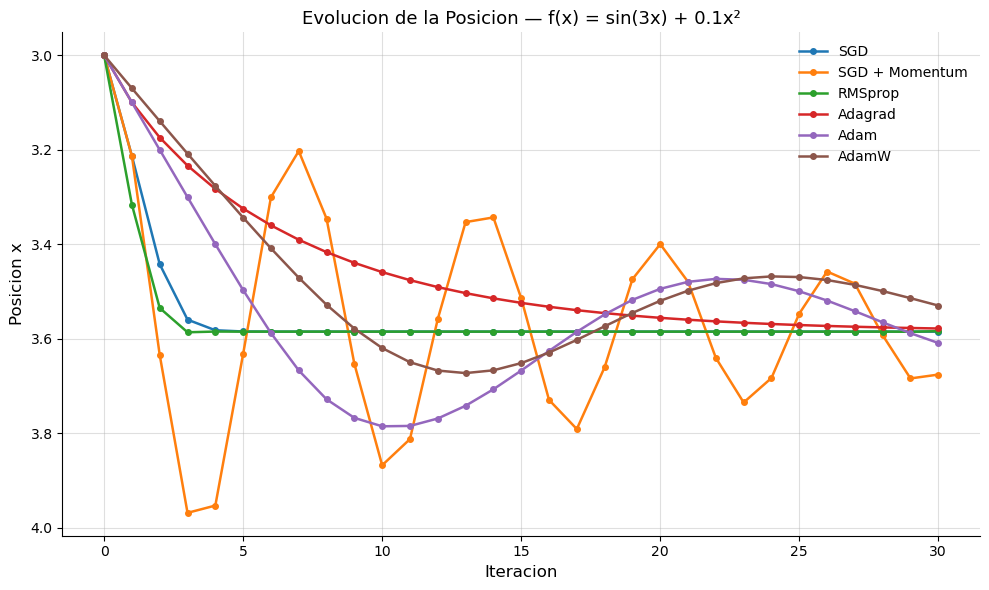

Grafico de trayectorias generado.


In [17]:
# ============================================================
# Visualizacion: Evolucion de la Posicion por Iteracion
# ============================================================
# Propósito: Mostrar cómo cada optimizador recorre el eje x
# a lo largo de las iteraciones. El eje Y invertido pone los
# valores más negativos (mínimos) en la parte superior,
# facilitando la lectura como "descenso hacia el óptimo".
#
# Que observar:
#   - Curvas suaves  → convergencia estable
#   - Curvas con zigzag → oscilaciones por gradiente ruidoso
#   - Curvas que se estancan → atrapadas en mínimos locales
# ============================================================

fig, eje = plt.subplots(figsize=(10, 6))

for nombre_metodo, posiciones in trayectorias_comparadas.items():
    eje.plot(
        range(ITERACIONES + 1),
        posiciones,
        label=nombre_metodo,
        marker="o",
        markersize=4,
        linewidth=1.8
    )

eje.set_xlabel("Iteracion", fontsize=12)
eje.set_ylabel("Posicion x", fontsize=12)
eje.set_title("Evolucion de la Posicion — f(x) = sin(3x) + 0.1x²", fontsize=13)
eje.legend(frameon=False)
eje.grid(True, alpha=0.4)
eje.invert_yaxis()   # Valores menores (minimos) se leen arriba
eje.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Grafico de trayectorias generado.")

In [18]:
# ============================================================
# Tabla Comparativa: Conceptos, Ventajas y Casos de Uso
# ============================================================
# Propósito: Complementar los gráficos con una síntesis
# cualitativa. Ver la ecuación implementada arriba junto a
# esta tabla permite conectar la mecánica con la intuición.
# ============================================================

resumen_optimizadores = {
    "Optimizador": [
        "SGD", "SGD + Momentum", "RMSprop",
        "Adagrad", "Adam", "AdamW"
    ],
    "Mecanismo clave": [
        "Descenso directo con tasa fija.",
        "Acumula velocidad del gradiente.",
        "Normaliza el paso con media movil de g².",
        "Normaliza con historial completo de g².",
        "Momentum + segundo momento adaptativo.",
        "Adam con weight decay desacoplado."
    ],
    "Ventaja principal": [
        "Simple y eficiente en problemas convexos.",
        "Reduce oscilaciones, acelera convergencia.",
        "Evita la caida agresiva de lr de Adagrad.",
        "Estable con datos dispersos.",
        "Rapido y estable en redes profundas.",
        "Mejor generalizacion en modelos grandes."
    ],
    "Limitacion principal": [
        "Se atasca en minimos locales.",
        "Puede sobrepasar el optimo.",
        "Sensible al ajuste de beta.",
        "lr decae hasta volverse insignificante.",
        "Computacionalmente mas costoso que SGD.",
        "Similar a Adam con costo marginal mayor."
    ],
    "Mejor caso de uso": [
        "Problemas convexos o entrenamientos rapidos.",
        "Redes neuronales profundas.",
        "Redes recurrentes (RNN, LSTM).",
        "NLP con vocabularios dispersos.",
        "Deep learning en general.",
        "Modelos grandes donde la regularizacion importa."
    ]
}

tabla_optimizadores = pd.DataFrame(resumen_optimizadores)
display(tabla_optimizadores)

print("Tabla comparativa generada.")

,Optimizador,Mecanismo clave,Ventaja principal,Limitacion principal,Mejor caso de uso
0,SGD,Descenso directo con tasa fija.,Simple y eficiente en problemas convexos.,Se atasca en minimos locales.,Problemas convexos o entrenamientos rapidos.
1,SGD + Momentum,Acumula velocidad del gradiente.,"Reduce oscilaciones, acelera convergencia.",Puede sobrepasar el optimo.,Redes neuronales profundas.
2,RMSprop,Normaliza el paso con media movil de g².,Evita la caida agresiva de lr de Adagrad.,Sensible al ajuste de beta.,"Redes recurrentes (RNN, LSTM)."
3,Adagrad,Normaliza con historial completo de g².,Estable con datos dispersos.,lr decae hasta volverse insignificante.,NLP con vocabularios dispersos.
4,Adam,Momentum + segundo momento adaptativo.,Rapido y estable en redes profundas.,Computacionalmente mas costoso que SGD.,Deep learning en general.
5,AdamW,Adam con weight decay desacoplado.,Mejor generalizacion en modelos grandes.,Similar a Adam con costo marginal mayor.,Modelos grandes donde la regularizacion importa.


Tabla comparativa generada.
